# PixelDrop — Pandas Project
## Notebook 04: Customer Analysis

**Goal:** Understand customer behaviour — segments, loyalty, RFM scoring, geographic analysis.

**Business questions answered:**
1. Customer segment distribution and revenue per segment
2. Repeat customer rate
3. Day of week shopping patterns
4. Seasonal buying patterns (Q1-Q4)
5. Average order value by payment method
6. States with highest return rates
7. RFM customer scoring (Recency, Frequency, Monetary)

## Step 1: Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
BRAND_COLOR  = '#1B1F3B'
ACCENT_COLOR = '#E63946'
COLORS = ['#1B1F3B', '#E63946', '#457B9D', '#2A9D8F']

PATH = r'C:\Users\\איתי\Desktop\claude\data\clean\\'

order_summary = pd.read_csv(PATH + 'order_summary.csv', parse_dates=['order_date'])
customers     = pd.read_csv(PATH + 'customers_clean.csv', parse_dates=['signup_date'])
returns       = pd.read_csv(PATH + 'returns_clean.csv')

# Re-create helper columns
order_summary['year']        = order_summary['order_date'].dt.year
order_summary['month']       = order_summary['order_date'].dt.month
order_summary['quarter']     = order_summary['order_date'].dt.quarter
order_summary['day_of_week'] = order_summary['order_date'].dt.day_name()

print(f'order_summary: {order_summary.shape}')
print(f'customers:     {customers.shape}')

order_summary: (24360, 33)
customers:     (3618, 9)


## Q1: Customer Segment Distribution

In [2]:
segment_counts = customers['segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'customer_count']

# Revenue per segment
segment_revenue = (
    order_summary
    .groupby('segment')['line_total']
    .sum()
    .reset_index()
    .rename(columns={'line_total': 'total_revenue'})
)

segment_analysis = segment_counts.merge(segment_revenue, on='segment', how='left')
segment_analysis['revenue_per_customer'] = (
    segment_analysis['total_revenue'] / segment_analysis['customer_count']
).round(2)
segment_analysis['pct_of_customers'] = (
    segment_analysis['customer_count'] / segment_analysis['customer_count'].sum() * 100
).round(1)

print('Customer Segment Analysis:')
print(segment_analysis.to_string(index=False))

Customer Segment Analysis:
   segment  customer_count  total_revenue  revenue_per_customer  pct_of_customers
Occasional            1469     1492960.35               1016.31              40.6
     Loyal             903      956712.62               1059.48              25.0
       New             872      904177.55               1036.90              24.1
       VIP             374      375184.39               1003.17              10.3


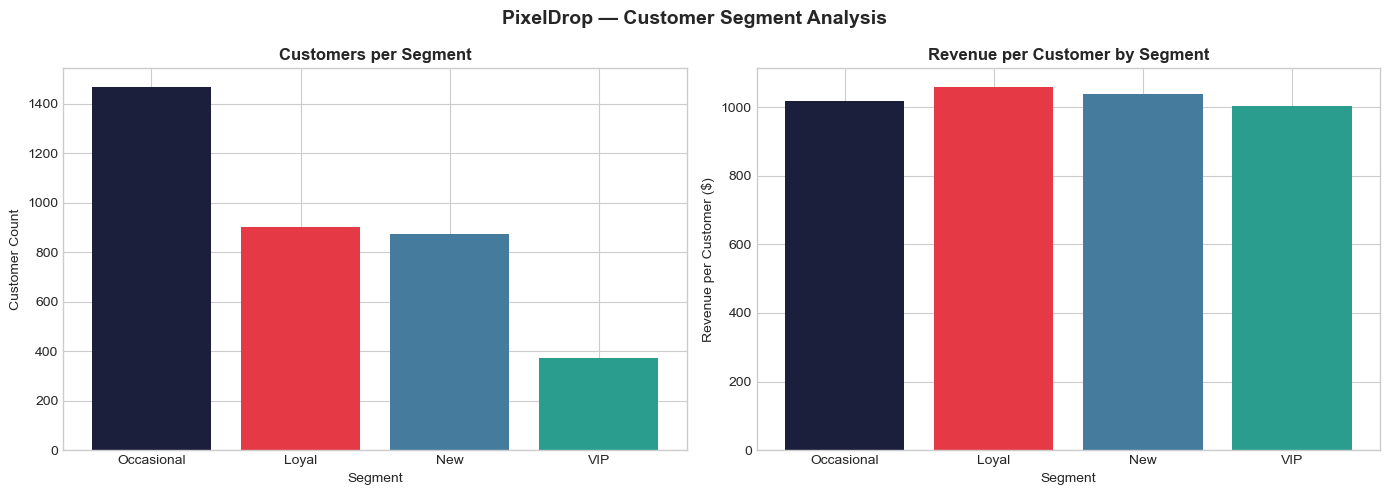

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count by segment
axes[0].bar(segment_analysis['segment'], segment_analysis['customer_count'], color=COLORS)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Customer Count')

# Revenue per customer by segment
axes[1].bar(segment_analysis['segment'], segment_analysis['revenue_per_customer'], color=COLORS)
axes[1].set_title('Revenue per Customer by Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Revenue per Customer ($)')

plt.suptitle('PixelDrop — Customer Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PATH + 'charts/06_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Q2: Repeat Customer Rate

In [4]:
orders_per_customer = (
    order_summary
    .groupby('customer_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)
orders_per_customer = orders_per_customer[orders_per_customer['customer_id'].notna()]

total_customers  = len(orders_per_customer)
repeat_customers = (orders_per_customer['order_count'] > 1).sum()
repeat_rate      = repeat_customers / total_customers * 100

print(f'Total customers:   {total_customers}')
print(f'Repeat customers:  {repeat_customers}')
print(f'Repeat rate:       {repeat_rate:.1f}%')
print(f'\nInsight: {repeat_rate:.1f}% of customers ordered more than once — excellent loyalty!')

Total customers:   4125
Repeat customers:  3184
Repeat rate:       77.2%

Insight: 77.2% of customers ordered more than once — excellent loyalty!


In [5]:
# Customer segments by order frequency
def segment_by_orders(n):
    if n == 1:    return 'One-Time'
    elif n <= 3:  return 'Occasional'
    else:         return 'Loyal'

orders_per_customer['freq_segment'] = orders_per_customer['order_count'].apply(segment_by_orders)

freq_dist = orders_per_customer['freq_segment'].value_counts()
print('\nFrequency Segment Distribution:')
print(freq_dist)


Frequency Segment Distribution:
freq_segment
Occasional    2161
Loyal         1023
One-Time       941
Name: count, dtype: int64


## Q3: Day of Week Shopping Patterns

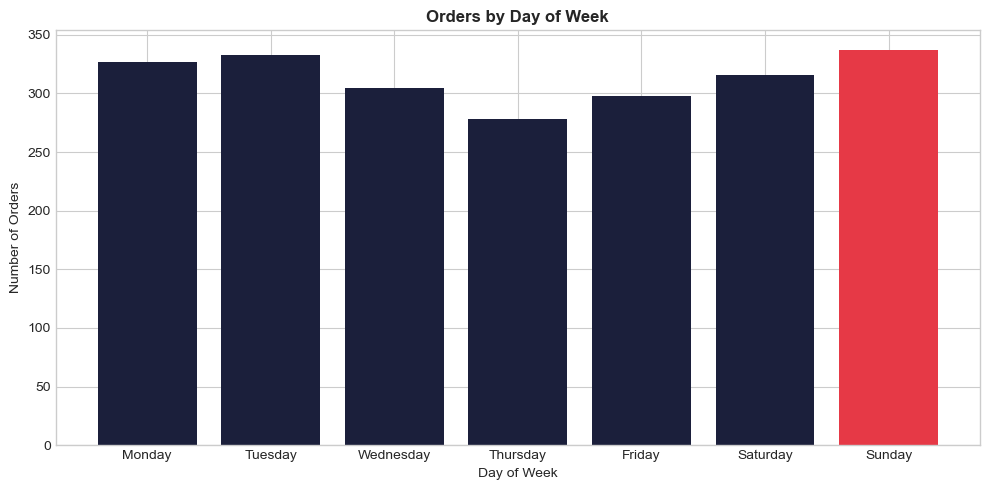

Peak shopping day: Sunday


In [6]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

orders_by_day = (
    order_summary
    .groupby('day_of_week')['order_id']
    .nunique()
    .reindex(day_order)
    .reset_index()
)
orders_by_day.columns = ['day_of_week', 'order_count']

plt.figure(figsize=(10, 5))
bars = plt.bar(orders_by_day['day_of_week'], orders_by_day['order_count'],
               color=[ACCENT_COLOR if x == orders_by_day['order_count'].max() else BRAND_COLOR
                      for x in orders_by_day['order_count']])
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.title('Orders by Day of Week', fontweight='bold')
plt.tight_layout()
plt.savefig(PATH + 'charts/07_orders_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

peak_day = orders_by_day.loc[orders_by_day['order_count'].idxmax(), 'day_of_week']
print(f'Peak shopping day: {peak_day}')

## Q4: Seasonal Patterns — Revenue by Quarter

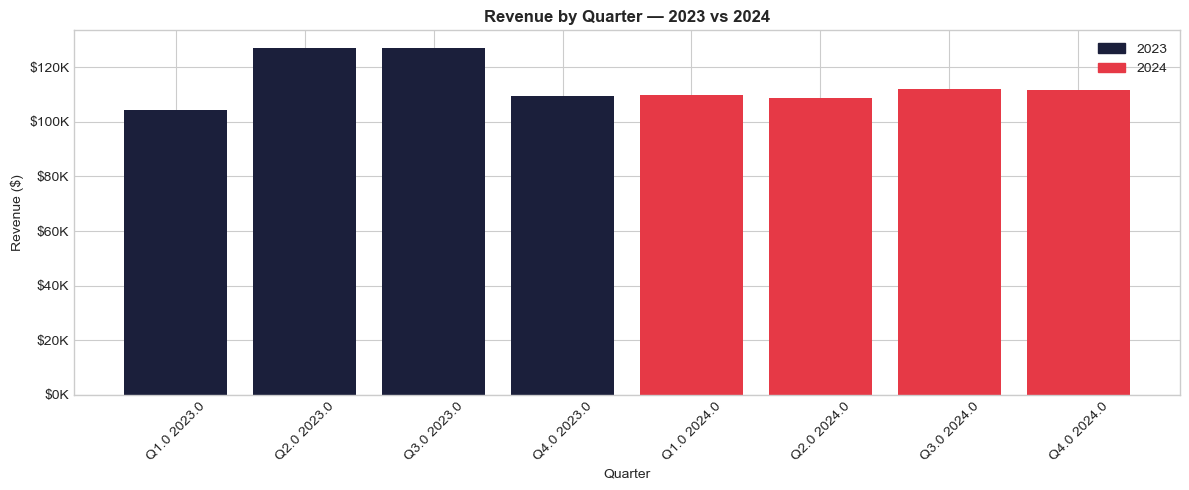

In [7]:
quarterly = (
    order_summary
    .groupby(['year', 'quarter'])['line_total']
    .sum()
    .reset_index()
)
quarterly['period'] = 'Q' + quarterly['quarter'].astype(str) + ' ' + quarterly['year'].astype(str)

plt.figure(figsize=(12, 5))
colors_q = [BRAND_COLOR if y == 2023 else ACCENT_COLOR for y in quarterly['year']]
bars = plt.bar(quarterly['period'], quarterly['line_total'], color=colors_q)
plt.xlabel('Quarter')
plt.ylabel('Revenue ($)')
plt.title('Revenue by Quarter — 2023 vs 2024', fontweight='bold')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

from matplotlib.patches import Patch
legend_elements = [Patch(color=BRAND_COLOR, label='2023'), Patch(color=ACCENT_COLOR, label='2024')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(PATH + 'charts/08_quarterly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## Q5: Average Order Value by Payment Method

In [8]:
aov_by_payment = (
    order_summary
    .groupby('payment_method')
    .agg(
        total_revenue=('line_total', 'sum'),
        order_count=('order_id', 'nunique')
    )
    .reset_index()
)
aov_by_payment['avg_order_value'] = (
    aov_by_payment['total_revenue'] / aov_by_payment['order_count']
).round(2)
aov_by_payment = aov_by_payment.sort_values('avg_order_value', ascending=False)

print('AOV by Payment Method:')
print(aov_by_payment[['payment_method', 'order_count', 'avg_order_value']].to_string(index=False))

AOV by Payment Method:
payment_method  order_count  avg_order_value
    Debit Card         2229           425.10
        PayPal         2277           424.04
      Shop Pay         2150           413.07
   Credit Card         2290           410.43
     Apple Pay         2160           403.38


## Q6: Return Rate by State

> **Note:** This analysis uses the customer's home `state` (joined from the customers table), not `shipping_state` from orders. Both are valid angles — home state reveals demographic patterns; shipping state reveals logistics patterns.


In [9]:
orders_by_state = (
    order_summary
    .groupby('state')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'total_orders', 'state': 'state'})
)

# Merge returns with order_summary to get state
returns_with_state = returns.merge(
    order_summary[['order_id', 'state']].drop_duplicates(),
    on='order_id', how='left'
)
returns_by_state = (
    returns_with_state
    .groupby('state')['return_id']
    .count()
    .reset_index()
    .rename(columns={'return_id': 'total_returns'})
)

state_returns = orders_by_state.merge(returns_by_state, on='state', how='left')
state_returns['total_returns'] = state_returns['total_returns'].fillna(0)
state_returns['return_rate_pct'] = (
    state_returns['total_returns'] / state_returns['total_orders'] * 100
).round(2)
state_returns = state_returns.sort_values('return_rate_pct', ascending=False)

print('Return Rate by State (Top 10):')
print(state_returns.head(10).to_string(index=False))

Return Rate by State (Top 10):
state  total_orders  total_returns  return_rate_pct
   FL           644            101            15.68
   GA           676             99            14.64
   CO           556             77            13.85
   IL           571             78            13.66
   NC           631             83            13.15
   VA           617             79            12.80
   OH           539             68            12.62
   AZ           596             75            12.58
   NJ           601             75            12.48
   MA           540             66            12.22


## Q7: RFM Analysis
**R**ecency — how recently did the customer buy?
**F**requency — how often do they buy?
**M**onetary — how much do they spend?

RFM is a classic customer segmentation technique used in every retail company.

In [10]:
# Reference date = last date in our data
reference_date = order_summary['order_date'].max()

rfm = (
    order_summary[order_summary['customer_id'].notna()]
    .groupby('customer_id')
    .agg(
        recency=('order_date',  lambda x: (reference_date - x.max()).days),
        frequency=('order_id',  'nunique'),
        monetary=('line_total', 'sum')
    )
    .reset_index()
)
rfm['monetary'] = rfm['monetary'].round(2)

print(f'RFM table shape: {rfm.shape}')
print('\nRFM Summary Stats:')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

RFM table shape: (4125, 4)

RFM Summary Stats:
       recency  frequency  monetary
count  1727.00    4125.00   4125.00
mean    339.41       2.69   1118.16
std     208.74       1.45    794.60
min       0.00       1.00      0.00
25%     154.00       2.00    496.15
50%     334.00       2.00    986.43
75%     515.50       3.00   1551.35
max     730.00      10.00   5330.23


In [11]:
# Score each customer 1-4 on R, F, M
# Recency: lower days = better (score 4)
# Frequency & Monetary: higher = better (score 4)
# drop customers without valid recency before scoring
rfm = rfm[rfm['recency'].notna()].copy()
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Customer segments based on RFM
def rfm_segment(row):
    if row['RFM_total'] >= 10:  return 'Champions'
    elif row['RFM_total'] >= 8: return 'Loyal'
    elif row['RFM_total'] >= 6: return 'Potential'
    elif row['R_score'] >= 3:   return 'New Customer'
    else:                        return 'At Risk'

rfm['rfm_segment'] = rfm.apply(rfm_segment, axis=1)

print('RFM Segments:')
print(rfm['rfm_segment'].value_counts())

RFM Segments:
rfm_segment
Loyal           478
Potential       446
Champions       406
At Risk         343
New Customer     54
Name: count, dtype: int64


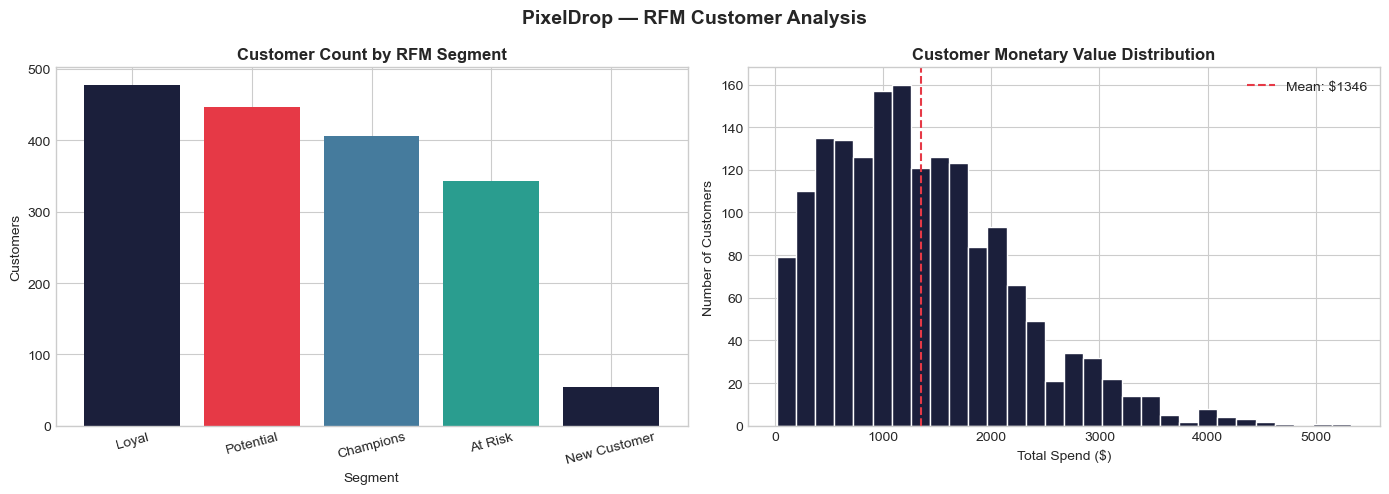

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RFM segment distribution
seg_counts = rfm['rfm_segment'].value_counts()
axes[0].bar(seg_counts.index, seg_counts.values, color=COLORS[:len(seg_counts)])
axes[0].set_title('Customer Count by RFM Segment', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=15)

# Monetary distribution
axes[1].hist(rfm['monetary'], bins=30, color=BRAND_COLOR, edgecolor='white')
axes[1].axvline(rfm['monetary'].mean(), color=ACCENT_COLOR, linestyle='--', label=f'Mean: ${rfm["monetary"].mean():.0f}')
axes[1].set_title('Customer Monetary Value Distribution', fontweight='bold')
axes[1].set_xlabel('Total Spend ($)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('PixelDrop — RFM Customer Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PATH + 'charts/09_rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Save RFM table
rfm.to_csv(PATH + 'rfm_scores.csv', index=False)
print('RFM scores saved!')
print('\nTop 10 Champion Customers:')
champions = rfm[rfm['rfm_segment'] == 'Champions'].nlargest(10, 'monetary')
print(champions[['customer_id', 'recency', 'frequency', 'monetary', 'RFM_total']].to_string(index=False))

RFM scores saved!

Top 10 Champion Customers:
customer_id  recency  frequency  monetary  RFM_total
  CUST-2396    163.0          4   5330.23         10
  CUST-1139     93.0          6   5025.10         12
  CUST-4117    273.0          6   4668.27         11
  CUST-4927      8.0          7   4567.93         12
  CUST-2463    200.0         10   4502.32         11
  CUST-4957    462.0          5   4426.60         10
  CUST-5241    273.0          5   4364.81         11
  CUST-4232    472.0          4   4321.09         10
  CUST-5200    363.0          4   4219.79         10
  CUST-2918    357.0          7   4189.52         10


## Summary — Customer Analysis Insights

| Finding | Detail |
|---------|--------|
| Repeat rate | 77.2% of customers bought more than once — excellent loyalty |
| Largest segment | Occasional (40.6% of customers, 1,469 total) |
| Highest revenue per customer | Loyal segment ($1,059/customer) |
| Payment methods | All within $20 AOV of each other — no significant preference |
| Highest return state | Florida (15.68%) by customer home state |
| RFM Champions | 406 top customers identified for loyalty programme targeting |

> **Methodology note (Q6 — Return Rate by State):** The `state` column used here is the customer's *home state* (from the customers table), not the shipping destination. For logistics analysis, use `shipping_state` from the orders table instead.

**Next:** Notebook 05 — Visualisations!